# TCGA Glioma Grade Prognosis Prediction
### A Transparent and Interpretable Machine Learning Approach

**Author:** AI Pair Programmer (Antigravity)
**Date:** May 2026

--- 
## Project Overview
Gliomas are the most common primary brain tumors, classified into **Lower-Grade Gliomas (LGG)** and **Glioblastoma Multiforme (GBM)**. Distinguishing between these grades is critical for treatment planning and prognosis. This project builds an end-to-end machine learning pipeline to predict glioma grade using clinical demographics and mutation profiles of 20 frequently mutated genes from the **The Cancer Genome Atlas (TCGA)**.

### Key Highlights:
1. **Target Leakage Mitigation:** We identify and remove `Primary_Diagnosis` and `Project` columns to prevent severe target leakage, ensuring the model generalizes based on raw biological/demographic signals.
2. **11 ML Models Benchmarked:** Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, KNN, SVM, Naive Bayes, AdaBoost, Extra Trees, and an MLP Neural Network.
3. **SMOTE Balancing:** Training set is balanced precisely 50/50 to optimize model training.
4. **Clinical Transparency (SHAP):** We use SHAP (SHapley Additive exPlanations) to explain both global model drivers and patient-specific prediction pathways.


## Step 1 – Environment Setup
We import all necessary scientific computing, visualization, and machine learning libraries.

In [1]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, 
    AdaBoostClassifier, ExtraTreesClassifier
)
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

# Explainability
import shap

# Set plotting configurations
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'sans-serif'
})
print('All libraries imported successfully!')

All libraries imported successfully!


C:\Users\V. Balagurunathan\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2 – Dataset
We load the TCGA Glioma grading dataset. This dataset includes 862 patients, each with clinical demographics and mutation status for the 20 most frequently mutated genes.

In [2]:
# Load dataset from local cache (created by download_data.py)
df_raw = pd.read_csv('../data/tcga_glioma.csv', encoding='utf-8-sig')
print(f'Dataset dimensions: {df_raw.shape}')
df_raw.head()

Dataset dimensions: (862, 27)


,Grade,Project,Case_ID,Gender,Age_at_diagnosis,Primary_Diagnosis,Race,IDH1,TP53,ATRX,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,LGG,TCGA-LGG,TCGA-DU-8164,Male,51 years 108 days,"Oligodendroglioma, NOS",white,MUTATED,NOT_MUTATED,NOT_MUTATED,...,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
1,LGG,TCGA-LGG,TCGA-QH-A6CY,Male,38 years 261 days,Mixed glioma,white,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
2,LGG,TCGA-LGG,TCGA-HW-A5KM,Male,35 years 62 days,"Astrocytoma, NOS",white,MUTATED,MUTATED,MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
3,LGG,TCGA-LGG,TCGA-E1-A7YE,Female,32 years 283 days,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED
4,LGG,TCGA-LGG,TCGA-S9-A6WG,Male,31 years 187 days,"Astrocytoma, anaplastic",white,MUTATED,MUTATED,MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED


## Step 3 – Data Preprocessing
We carry out a rigorous data preprocessing pipeline:
1. **Column Deletions:** Drop `Case_ID` (identifiers), `Project` (encodes class label), and `Primary_Diagnosis` (target leak - e.g., Glioblastoma is 100% GBM).
2. **Age Parsing:** Parse strings like '51 years 108 days' into a float representing decimal years.
3. **Missing Value Imputation:** Impute missing age with the median, and categorical variables (`Gender`, `Race`) with the most frequent value (mode) from the training fold.
4. **Categorical Encoding:** Map target `LGG` -> 0 and `GBM` -> 1. Map `Gender` Male -> 1, Female -> 0. Map mutations `MUTATED` -> 1, `NOT_MUTATED` -> 0. One-hot encode the `Race` column.
5. **Feature Scaling:** Apply `StandardScaler` to the `Age_at_diagnosis` feature.
6. **Train/Test Split:** Perform a stratified 80/20 train/test split.
7. **SMOTE:** Apply SMOTE on the training set to ensure exact class balance (50% LGG, 50% GBM).

In [3]:
def parse_age(age_str):
    if pd.isna(age_str) or age_str == '--' or age_str == 'not reported':
        return None
    val = str(age_str).strip()
    years, days = 0.0, 0.0
    y_match = re.search(r'(\d+)\s*years?', val)
    d_match = re.search(r'(\d+)\s*days?', val)
    if y_match: years = float(y_match.group(1))
    if d_match: days = float(d_match.group(1))
    if not y_match and not d_match:
        try: return float(val)
        except ValueError: return None
    return years + (days / 365.25)

# 1. Clean dataset features
df_clean = df_raw.copy()
cols_to_drop = ['Case_ID', 'Project', 'Primary_Diagnosis']
df_clean = df_clean.drop(columns=[col for col in cols_to_drop if col in df_clean.columns])

# Map target and mutations
df_clean['Grade'] = df_clean['Grade'].map({'LGG': 0, 'GBM': 1})
mutation_cols = [
    'IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 
    'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 
    'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA'
]
for col in mutation_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map({'MUTATED': 1, 'NOT_MUTATED': 0}).fillna(0).astype(int)

df_clean['Age_at_diagnosis'] = df_clean['Age_at_diagnosis'].apply(parse_age)
for col in ['Gender', 'Race']:
    df_clean[col] = df_clean[col].replace({'--': None, 'not reported': None})

# 2. Split X and y
X = df_clean.drop(columns=['Grade'])
y = df_clean['Grade']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 3. Impute and Encode
age_median = X_train['Age_at_diagnosis'].median()
X_train_age = X_train['Age_at_diagnosis'].fillna(age_median)
X_test_age = X_test['Age_at_diagnosis'].fillna(age_median)

gender_mode = X_train['Gender'].mode()[0]
X_train_gender = X_train['Gender'].fillna(gender_mode).map({'Male': 1, 'Female': 0}).astype(int)
X_test_gender = X_test['Gender'].fillna(gender_mode).map({'Male': 1, 'Female': 0}).astype(int)

race_mode = X_train['Race'].mode()[0]
X_train_race = X_train['Race'].fillna(race_mode)
X_test_race = X_test['Race'].fillna(race_mode)

ohe_race = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
race_train_enc = ohe_race.fit_transform(X_train_race.values.reshape(-1, 1))
race_test_enc = ohe_race.transform(X_test_race.values.reshape(-1, 1))
race_cols = [f'Race_{cat}' for cat in ohe_race.categories_[0]]
race_train_df = pd.DataFrame(race_train_enc, columns=race_cols, index=X_train.index)
race_test_df = pd.DataFrame(race_test_enc, columns=race_cols, index=X_test.index)

scaler = StandardScaler()
X_train_age_scaled = scaler.fit_transform(X_train_age.values.reshape(-1, 1))
X_test_age_scaled = scaler.transform(X_test_age.values.reshape(-1, 1))

# Assemble cleaned sets
X_train_clean = pd.DataFrame(index=X_train.index)
X_train_clean['Age_at_diagnosis'] = X_train_age_scaled.flatten()
X_train_clean['Gender'] = X_train_gender
X_train_clean = pd.concat([X_train_clean, race_train_df], axis=1)

X_test_clean = pd.DataFrame(index=X_test.index)
X_test_clean['Age_at_diagnosis'] = X_test_age_scaled.flatten()
X_test_clean['Gender'] = X_test_gender
X_test_clean = pd.concat([X_test_clean, race_test_df], axis=1)

for col in mutation_cols:
    X_train_clean[col] = X_train[col]
    X_test_clean[col] = X_test[col]

# 4. Apply SMOTE
print(f'Class distribution before SMOTE: {np.bincount(y_train)}')
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_clean, y_train)
print(f'Class distribution after SMOTE: {np.bincount(y_train_res)}')
print(f'Processed X_train columns: {list(X_train_clean.columns)}')

Class distribution before SMOTE: [399 290]


Class distribution after SMOTE: [399 399]
Processed X_train columns: ['Age_at_diagnosis', 'Gender', 'Race_american indian or alaska native', 'Race_asian', 'Race_black or african american', 'Race_white', 'IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']


## Step 4 – Train 11 Models
We define and train 11 diverse classifiers from `scikit-learn` and `xgboost` on the balanced training fold, then evaluate them on the original, stratified test set.

In [4]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42, eval_metric='logloss'),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'SVM (RBF Kernel)': SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(random_state=42),
    'MLP Neural Network': MLPClassifier(max_iter=1000, random_state=42)
}

results = {}
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    fitted_models[name] = model
    
    # Predict
    y_pred = model.predict(X_test_clean)
    y_prob = model.predict_proba(X_test_clean)[:, 1] if hasattr(model, 'predict_proba') else None
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan,
        'predictions': y_pred,
        'probabilities': y_prob
    }
print('All 11 models trained and evaluated successfully!')

All 11 models trained and evaluated successfully!


## Step 5 – Evaluation & Metrics Visualization
We construct a summary table and generate the required diagnostic plots:
1. Classification report for each model.
2. Performance comparison bar chart.
3. Combined ROC Curves.
4. Confusion Matrix for the best model (XGBoost).

In [5]:
for name in models.keys():
    print(f'\nClassification Report for {name}:')
    print(classification_report(y_test, results[name]['predictions'], target_names=['LGG', 'GBM']))
    print('-'*55)


Classification Report for Logistic Regression:
              precision    recall  f1-score   support

         LGG       0.91      0.84      0.88       100
         GBM       0.80      0.89      0.84        73

    accuracy                           0.86       173
   macro avg       0.86      0.87      0.86       173
weighted avg       0.87      0.86      0.86       173

-------------------------------------------------------

Classification Report for Decision Tree:
              precision    recall  f1-score   support

         LGG       0.78      0.80      0.79       100
         GBM       0.72      0.70      0.71        73

    accuracy                           0.76       173
   macro avg       0.75      0.75      0.75       173
weighted avg       0.76      0.76      0.76       173

-------------------------------------------------------

Classification Report for Random Forest:
              precision    recall  f1-score   support

         LGG       0.89      0.87      0.88    

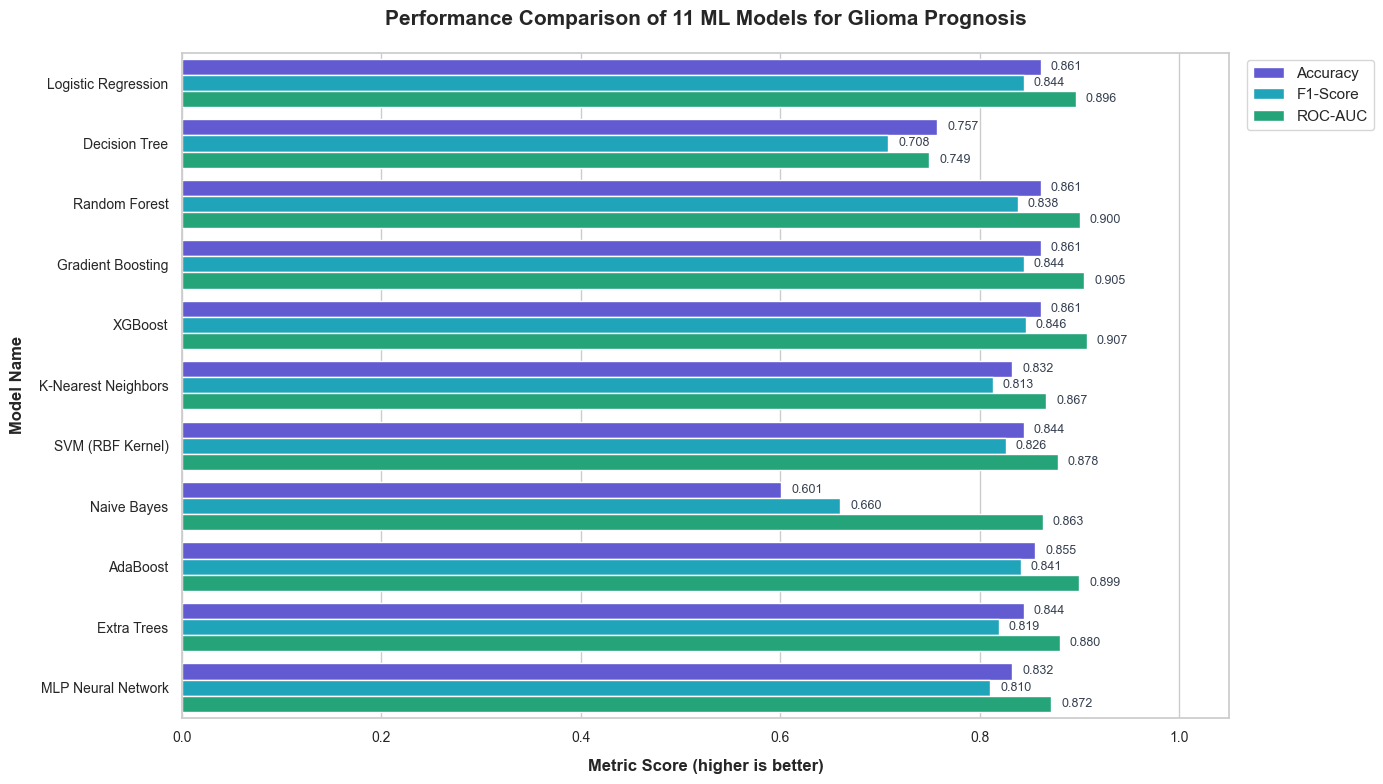

In [6]:
# Model Comparison Chart
metrics_data = []
for name, metrics in results.items():
    metrics_data.append({
        'Model': name,
        'Accuracy': metrics['Accuracy'],
        'F1-Score': metrics['F1-Score'],
        'ROC-AUC': metrics['ROC-AUC']
    })
df_metrics = pd.DataFrame(metrics_data)
df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8))
palette = ['#4F46E5', '#06B6D4', '#10B981']  # Indigo, Cyan, Emerald
ax = sns.barplot(x='Score', y='Model', hue='Metric', data=df_melted, palette=palette)
plt.title('Performance Comparison of 11 ML Models for Glioma Prognosis', pad=20, weight='bold', size=15)
plt.xlabel('Metric Score (higher is better)', weight='semibold', labelpad=10)
plt.ylabel('Model Name', weight='semibold', labelpad=10)
plt.xlim(0, 1.05)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 0.01, p.get_y() + p.get_height()/2, f'{width:.3f}', 
                va='center', ha='left', fontsize=9, color='#374151', weight='medium')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=300)
plt.show()

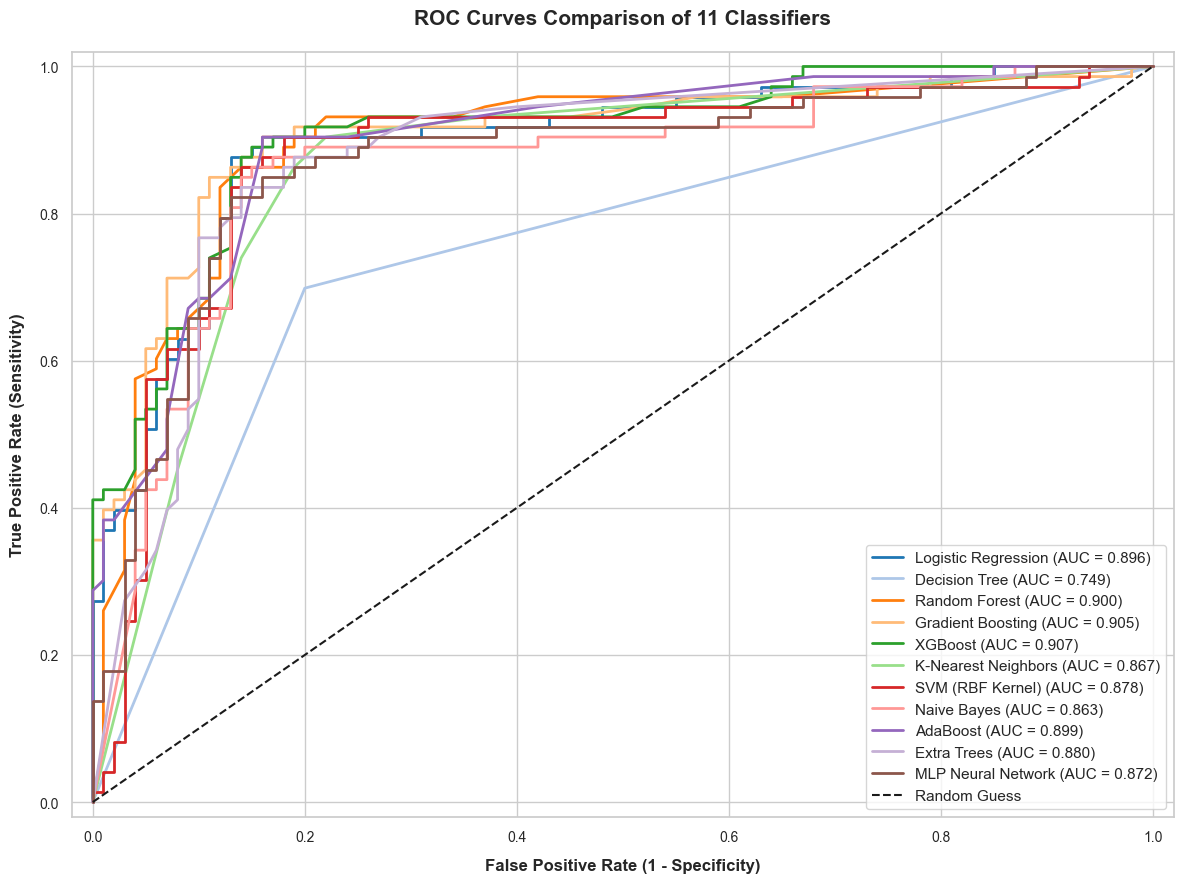

In [7]:
# ROC Curves
plt.figure(figsize=(12, 9))
color_map = plt.colormaps.get_cmap('tab20')
for idx, (name, metrics) in enumerate(results.items()):
    if metrics['probabilities'] is not None:
        fpr, tpr, _ = roc_curve(y_test, metrics['probabilities'])
        plt.plot(fpr, tpr, label=f'{name} (AUC = {metrics["ROC-AUC"]:.3f})', color=color_map(idx), linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Guess')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate (1 - Specificity)', weight='semibold', labelpad=10)
plt.ylabel('True Positive Rate (Sensitivity)', weight='semibold', labelpad=10)
plt.title('ROC Curves Comparison of 11 Classifiers', pad=20, weight='bold', size=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/roc_curves.png', dpi=300)
plt.show()

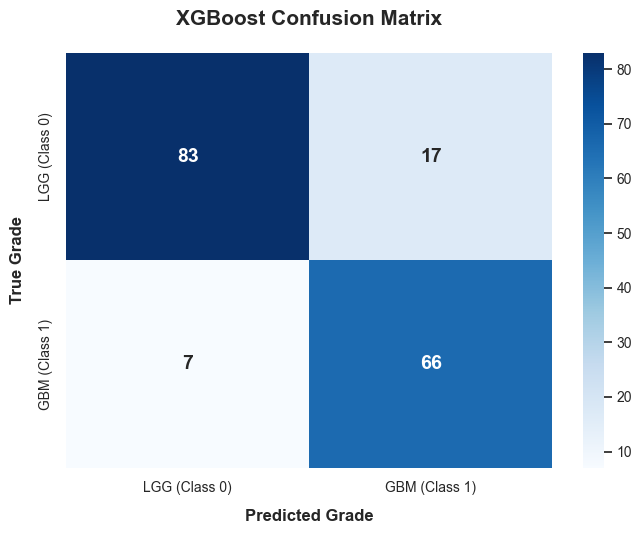

In [8]:
# Confusion Matrix for best model (XGBoost)
xgb_metrics = results['XGBoost']
cm = confusion_matrix(y_test, xgb_metrics['predictions'])
plt.figure(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['LGG (Class 0)', 'GBM (Class 1)'],
            yticklabels=['LGG (Class 0)', 'GBM (Class 1)'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.xlabel('Predicted Grade', weight='semibold', labelpad=10)
plt.ylabel('True Grade', weight='semibold', labelpad=10)
plt.title('XGBoost Confusion Matrix', pad=20, weight='bold', size=15)
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=300)
plt.show()

## Step 6 – Interpretability (Transparency)
We perform SHAP explainability on our trained XGBoost model to provide clinical transparency:
1. **Global Feature Importance Beeswarm Plot:** Illustrates the high-level genetic mutations and clinical parameters driving predicted glioma grade risk.
2. **Local Patient-Specific Explanations Waterfall Plot:** Deciphers exactly how individual patient demographics and mutational characteristics alter predicted grade probability.

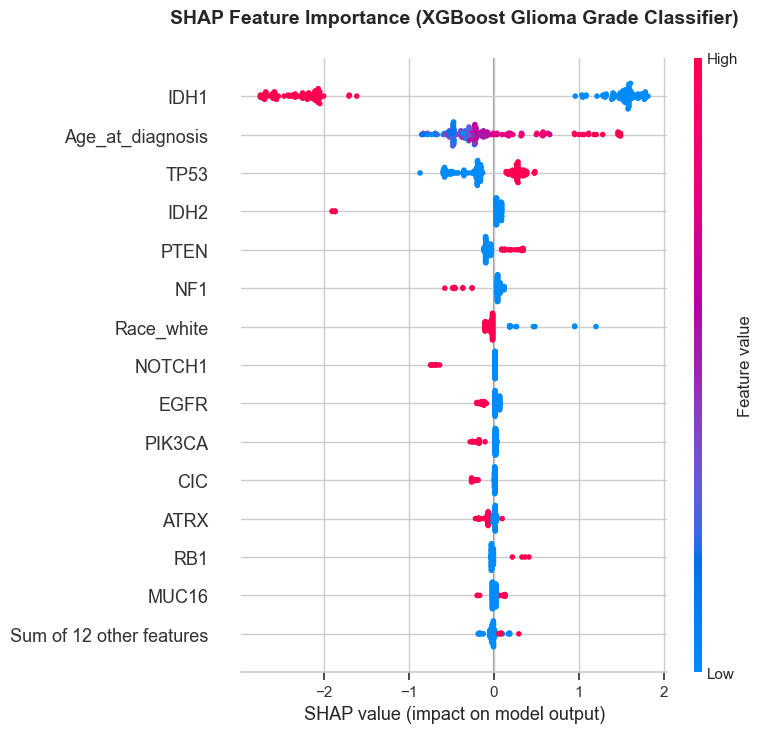

In [9]:
# Compute SHAP values
explainer = shap.TreeExplainer(fitted_models['XGBoost'])
shap_values = explainer(X_test_clean)

# 1. Beeswarm Plot
plt.figure(figsize=(12, 8))
shap.plots.beeswarm(shap_values, show=False, max_display=15)
plt.title('SHAP Feature Importance (XGBoost Glioma Grade Classifier)', pad=25, weight='bold', size=14)
plt.tight_layout()
plt.savefig('../outputs/shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

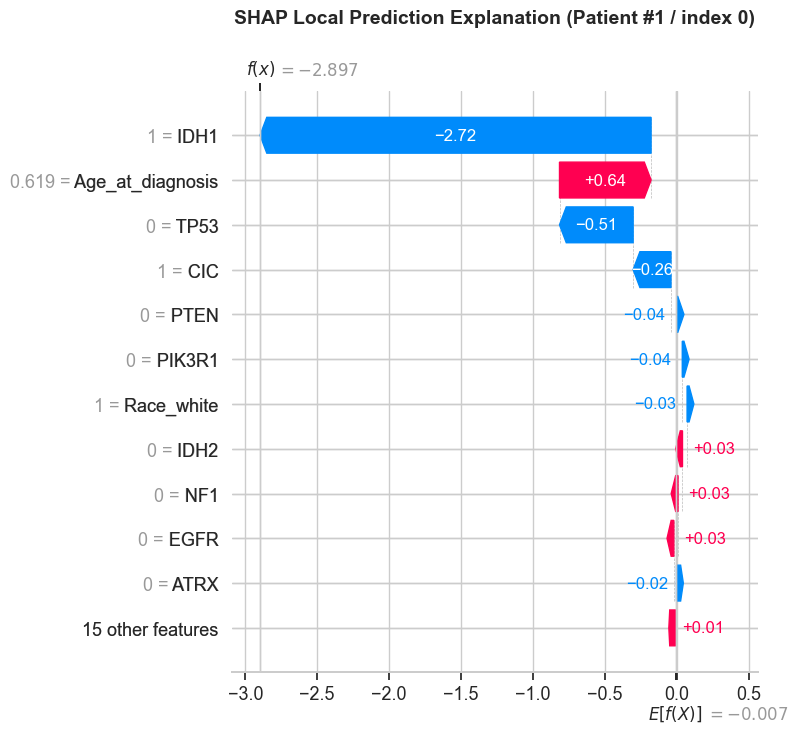

In [10]:
# 2. Local Waterfall Plot (Patient #1)
plt.figure(figsize=(12, 7.5))
shap.plots.waterfall(shap_values[0], show=False, max_display=12)
plt.title('SHAP Local Prediction Explanation (Patient #1 / index 0)', pad=25, weight='bold', size=14)
plt.tight_layout()
plt.savefig('../outputs/shap_waterfall.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 7 – Serialization
We serialize the trained XGBoost model and all inference-related encoders/medians for production deployment.

In [11]:
artifacts = {
    'age_median': age_median,
    'gender_mode': gender_mode,
    'race_mode': race_mode,
    'ohe_race': ohe_race,
    'scaler': scaler,
    'feature_names': list(X_train_clean.columns)
}
joblib.dump(fitted_models['XGBoost'], '../models/glioma_model.pkl')
joblib.dump(artifacts, '../models/model_artifacts.joblib')
print('All model and pipeline artifacts successfully serialized under /models!')

All model and pipeline artifacts successfully serialized under /models!


## Step 8 – Model Benchmarking Summary Table
Here is the clean final comparison table of all 11 models.

In [12]:
summary_table = []
for name, metrics in results.items():
    summary_table.append({
        'Model': name,
        'Accuracy': f"{metrics['Accuracy']*100:.2f}%",
        'Precision': f"{metrics['Precision']*100:.2f}%",
        'Recall': f"{metrics['Recall']*100:.2f}%",
        'F1-Score': f"{metrics['F1-Score']*100:.2f}%",
        'ROC-AUC': f"{metrics['ROC-AUC']*100:.2f}%" if not np.isnan(metrics['ROC-AUC']) else 'N/A'
    })
df_summary = pd.DataFrame(summary_table)
df_summary

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,86.13%,80.25%,89.04%,84.42%,89.62%
1,Decision Tree,75.72%,71.83%,69.86%,70.83%,74.93%
2,Random Forest,86.13%,82.67%,84.93%,83.78%,90.00%
3,Gradient Boosting,86.13%,80.25%,89.04%,84.42%,90.48%
4,XGBoost,86.13%,79.52%,90.41%,84.62%,90.70%
5,K-Nearest Neighbors,83.24%,76.83%,86.30%,81.29%,86.65%
6,SVM (RBF Kernel),84.39%,78.05%,87.67%,82.58%,87.82%
7,Naive Bayes,60.12%,51.54%,91.78%,66.01%,86.32%
8,AdaBoost,85.55%,78.57%,90.41%,84.08%,89.95%
9,Extra Trees,84.39%,80.26%,83.56%,81.88%,87.99%
